## Required Libraries


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading dataset

In [ ]:
df = pd.read_excel("dataset/Data.xlsx")
df.dropna(inplace=True)
df.head(5)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


## Data Type Conversion


In [26]:
df['Date_of_Journey']= pd.to_datetime(df['Date_of_Journey'])
df['Arrival_Time']= pd.to_datetime(df['Arrival_Time'])
df['Dep_Time']= pd.to_datetime(df['Dep_Time'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10682 non-null  object        
 1   Date_of_Journey  10682 non-null  datetime64[ns]
 2   Source           10682 non-null  object        
 3   Destination      10682 non-null  object        
 4   Route            10682 non-null  object        
 5   Dep_Time         10682 non-null  datetime64[ns]
 6   Arrival_Time     10682 non-null  datetime64[ns]
 7   Duration         10682 non-null  object        
 8   Total_Stops      10682 non-null  object        
 9   Additional_Info  10682 non-null  object        
 10  Price            10682 non-null  int64         
dtypes: datetime64[ns](3), int64(1), object(7)
memory usage: 1001.4+ KB


C:\Users\dell\AppData\Local\Temp\ipykernel_11492\3401785358.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date_of_Journey']= pd.to_datetime(df['Date_of_Journey'])
C:\Users\dell\AppData\Local\Temp\ipykernel_11492\3401785358.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Arrival_Time']= pd.to_datetime(df['Arrival_Time'])
C:\Users\dell\AppData\Local\Temp\ipykernel_11492\3401785358.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dep_Time']= pd.to_datetime(df['Dep_Time'])


## Initial Data Preprocessing

This section focuses on converting date and time features into numerical components that can be used by machine learning models.


In [27]:
df[ 'Date_of_Journey_day'] = df['Date_of_Journey'].dt.day
df[ 'Date_of_Journey_month'] = df['Date_of_Journey'].dt.month
df['Date_of_Journey_year'] = df['Date_of_Journey'].dt.year   

## Processing Departure and Arrival Time Features


In [ ]:
def extract_time_features(df, col):
    """
    Extracts hour and minute from time or datetime columns.
    Handles cases where the column contains date + time.
    """
    df[f"{col}_year"] = df[col].dt.year
    df[f"{col}_month"] = df[col].dt.month
    df[f"{col}_day"] = df[col].dt.day
    df[f"{col}_hour"] = df[col].dt.hour
    df[f"{col}_min"] = df[col].dt.minute
    return df

df = extract_time_features(df=df,col='Dep_Time')
df = extract_time_features(df=df,col='Arrival_Time')

Airline                  0
Date_of_Journey          0
Source                   0
Destination              0
Route                    0
Dep_Time                 0
Arrival_Time             0
Duration                 0
Total_Stops              0
Additional_Info          0
Price                    0
Date_of_Journey_day      0
Date_of_Journey_month    0
Date_of_Journey_year     0
Dep_Time_year            0
Dep_Time_month           0
Dep_Time_day             0
Dep_Time_hour            0
Dep_Time_min             0
Arrival_Time_year        0
Arrival_Time_month       0
Arrival_Time_day         0
Arrival_Time_hour        0
Arrival_Time_min         0
dtype: int64

## Feature Selection and Column Removal


In [ ]:
df_copy = df.copy()
df_copy.drop(axis=1,columns=['Dep_Time','Arrival_Time','Date_of_Journey'],inplace=True)

In [30]:
# df_copy['Arrival_Time_year'].unique()
# df_copy['Dep_Time_year'].unique()
# df_copy['Dep_Time_month'].unique()
# df_copy['Arrival_Time_month'].unique()
# df_copy['Additional_Info'].unique()
df_copy.drop(columns=['Arrival_Time_year','Dep_Time_year','Dep_Time_month','Additional_Info','Date_of_Journey_year'], axis = 1 , inplace = True )

## Transforming Duration into a Numerical Feature


In [31]:
hours = df_copy['Duration'].str.extract(r'(\d+)h').astype(float).fillna(0)
minutes = df_copy['Duration'].str.extract(r'(\d+)m').astype(float).fillna(0)

df_copy['Duration_Minutes'] = hours[0] * 60 + minutes[0]
df_copy.drop(columns = ['Duration'], axis = 1, inplace = True)


## Encoding Total Stops as a Numerical Feature


In [ ]:
df_copy['Total_Stops'].unique()
mapping = {
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
}

df_copy["Total_Stops"] = df_copy["Total_Stops"].map(mapping)

assert df_copy["Total_Stops"].isna().sum() == 0

Airline                  0
Source                   0
Destination              0
Route                    0
Total_Stops              0
Price                    0
Date_of_Journey_day      0
Date_of_Journey_month    0
Dep_Time_day             0
Dep_Time_hour            0
Dep_Time_min             0
Arrival_Time_month       0
Arrival_Time_day         0
Arrival_Time_hour        0
Arrival_Time_min         0
Duration_Minutes         0
dtype: int64

## Encoding Categorical Variables


In [33]:
# Encoding Airlines
df_copy['Airline'].unique()

array(['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet',
       'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia',
       'Vistara Premium economy', 'Jet Airways Business',
       'Multiple carriers Premium economy', 'Trujet'], dtype=object)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

airline_encoder = OneHotEncoder(
    drop="first",        
    sparse_output=False  
)

airline_encoded = airline_encoder.fit_transform(df_copy[["Airline"]])

encoded_df = pd.DataFrame(
    airline_encoded,
    columns=airline_encoder.get_feature_names_out(["Airline"])
)
encoded_df.index = df_copy.index
df_copy = pd.concat([df_copy.drop(columns=["Airline"]), encoded_df], axis=1)

Source                                       0
Destination                                  0
Route                                        0
Total_Stops                                  0
Price                                        0
Date_of_Journey_day                          0
Date_of_Journey_month                        0
Dep_Time_day                                 0
Dep_Time_hour                                0
Dep_Time_min                                 0
Arrival_Time_month                           0
Arrival_Time_day                             0
Arrival_Time_hour                            0
Arrival_Time_min                             0
Duration_Minutes                             0
Airline_Air India                            0
Airline_GoAir                                0
Airline_IndiGo                               0
Airline_Jet Airways                          0
Airline_Jet Airways Business                 0
Airline_Multiple carriers                    0
Airline_Multi

In [ ]:
# Select appropriate encoding strategies for categorical features.
# Since only a single missing value is present, the corresponding row is dropped.
df_copy['Source'].unique()
df_copy['Source'].isna().sum()

np.int64(0)

In [ ]:
source_encoder = OneHotEncoder(
    drop="first",   
     sparse_output=False  
)
source_encoded = source_encoder.fit_transform(df_copy[["Source"]])
encoded_df = pd.DataFrame(
    source_encoded,
    columns=source_encoder.get_feature_names_out(["Source"])
)
encoded_df.index = df_copy.index
df_copy = pd.concat([df_copy.drop(columns=["Source"]), encoded_df], axis=1)

In [37]:
df_copy['Route'].nunique()
df_copy.drop(columns=['Route'], axis = 1 , inplace = True )

In [ ]:
df_copy['Destination'].unique()
df_copy['Destination'].isna().sum()
df_copy['Destination'].replace('New Delhi','Delhi',inplace=True)
df_copy['Destination'].unique()
destination_encoder = OneHotEncoder(
    drop="first",        
    sparse_output=False  
)
destination_encoded = destination_encoder.fit_transform(df_copy[["Destination"]])
encoded_df = pd.DataFrame(
    destination_encoded, columns=destination_encoder.get_feature_names_out(["Destination"])
)
encoded_df.index = df_copy.index
df_copy = pd.concat([df_copy.drop(columns=["Destination"]), encoded_df], axis=1)

C:\Users\dell\AppData\Local\Temp\ipykernel_11492\3713877398.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['Destination'].replace('New Delhi','Delhi',inplace=True)


In [39]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 31 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Total_Stops                                10682 non-null  int64  
 1   Price                                      10682 non-null  int64  
 2   Date_of_Journey_day                        10682 non-null  int32  
 3   Date_of_Journey_month                      10682 non-null  int32  
 4   Dep_Time_day                               10682 non-null  int32  
 5   Dep_Time_hour                              10682 non-null  int32  
 6   Dep_Time_min                               10682 non-null  int32  
 7   Arrival_Time_month                         10682 non-null  int32  
 8   Arrival_Time_day                           10682 non-null  int32  
 9   Arrival_Time_hour                          10682 non-null  int32  
 10  Arrival_Time_min           

## Outlier Analysis and Price Distribution

The target variable (Price) is analyzed for outliers and skewness.

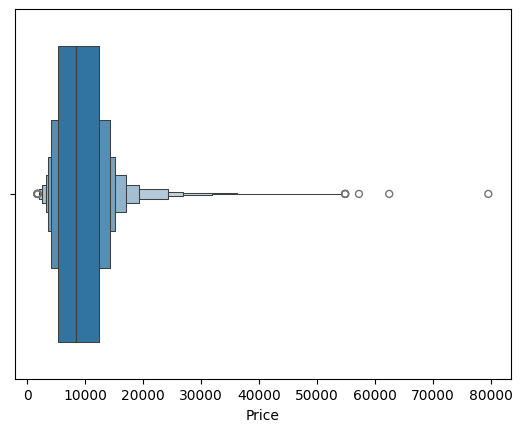

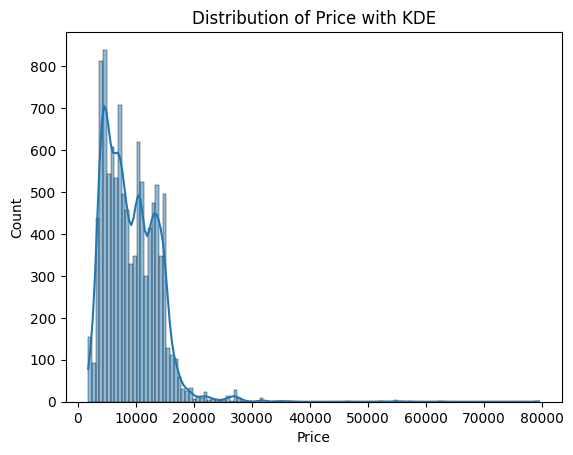

In [40]:
sns.boxenplot(x=df_copy['Price'])
plt.show()

sns.histplot(x=df_copy['Price'], kde=True)
plt.title('Distribution of Price with KDE')
plt.show()


In [ ]:
min,Q1,median,Q3,max = np.percentile(df_copy['Price'], [0, 25, 50, 75, 100])
lower_fence = Q1 - 1.5 * (Q3 - Q1)
upper_fence = Q3 + 1.5 * (Q3 - Q1)
df_copy['Price_capped'] = df_copy['Price'].clip(lower=lower_fence, upper=upper_fence)
df_copy["Price_log"] = np.log1p(df_copy["Price_capped"])
df_copy.drop(columns=['Price','Price_capped'], axis = 1 , inplace = True )

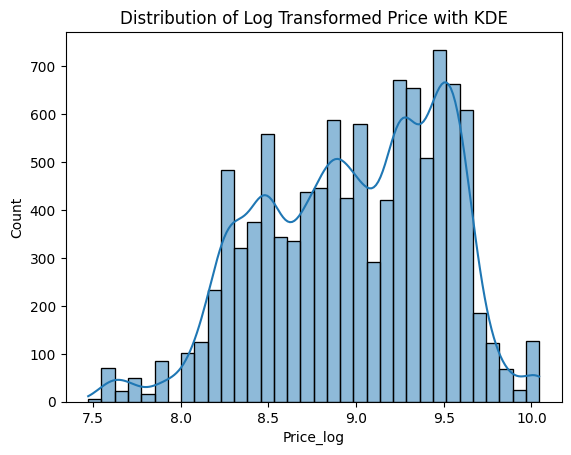

In [42]:
sns.histplot(x=df_copy['Price_log'], kde=True)
plt.title('Distribution of Log Transformed Price with KDE')
plt.show()

## Feature Selection
Feature relevance is assessed using mutual information regression, which measures
the dependency between each feature and the target variable.

In [ ]:
from sklearn.feature_selection import mutual_info_regression
X = df_copy.drop(columns=["Price_log"])

X.isna().sum().sort_values(ascending=False)

assert X.isna().sum().sum() == 0
y = df_copy['Price_log']
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
mi_scores

Duration_Minutes                             1.777410
Arrival_Time_hour                            1.135956
Dep_Time_hour                                0.920328
Arrival_Time_min                             0.895171
Total_Stops                                  0.792738
Dep_Time_min                                 0.752112
Date_of_Journey_month                        0.629649
Arrival_Time_month                           0.557058
Airline_Jet Airways                          0.544415
Source_Delhi                                 0.522904
Destination_Cochin                           0.518953
Source_Kolkata                               0.459296
Arrival_Time_day                             0.405947
Destination_Delhi                            0.390295
Date_of_Journey_day                          0.363981
Airline_IndiGo                               0.363805
Airline_Air India                            0.294326
Airline_Multiple carriers                    0.262734
Airline_SpiceJet            

## Model Choice: Random Forest

Random Forest is selected as the initial model due to its ability to capture
non-linear relationships, robustness to outliers, and strong performance on
structured tabular data.


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [46]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")    
print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")

Mean Absolute Error: 0.12086742286619323
Mean Squared Error: 0.03262510671852738
R-squared Score: 0.8766262002790258


A Dummy Regressor is used as a baseline to evaluate whether the trained model
provides predictive value beyond naive mean-based predictions. The Random
Forest model significantly outperforms the dummy baseline, confirming that it
learns meaningful patterns from the data.


In [ ]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)

print("Dummy R2:", r2_score(y_test, y_dummy))

Dummy R2: -0.0004080071467367219


## Linear Regression Model

A linear regression model is implemented as a baseline to evaluate how well the
relationship between the features and the target variable can be captured using
a linear approach.


In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])
pipeline.fit(X_train, y_train)
y_pred_lr = pipeline.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Linear Regression Mean Absolute Error: {mae_lr}")
print(f"Linear Regression Mean Squared Error: {mse_lr}")
print(f"Linear Regression R-squared Score: {r2_lr}")

Linear Regression Mean Absolute Error: 0.20301066980197882
Linear Regression Mean Squared Error: 0.07291778464724458
Linear Regression R-squared Score: 0.7242570197001844
